In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# --- Data Collection and Loading ---
# Dataset: Wine dataset from sklearn — 178 wine samples, 13 chemical measurements,
# from 3 different cultivars grown in the same region of Italy.

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

true_labels = wine.target

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully.
Shape: (178, 13)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_o

In [3]:
#Check for Missing Values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


In [5]:
 #Inspect the Data
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.5723

### Preprocessing Observations

The 13 features have very different scales — for example, `proline` values range up to ~1680,
while `hue` values are all under 2. Both K-Means (distance-based) and PCA (variance-based) are
sensitive to scale: without standardization, `proline` alone would dominate every distance
calculation and principal component simply because its raw numbers are larger, not because it's
actually more important. Standardization is therefore essential here

In [6]:
# --- Feature Scaling ---
# Standardize all features to mean=0, std=1, since K-Means and PCA are scale-sensitive

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert back to a DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("Before scaling:")
print(df.describe().loc[['mean', 'std']])
print("\nAfter scaling:")
print(X_scaled_df.describe().loc[['mean', 'std']])

Before scaling:
        alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
mean  13.000618    2.336348  2.366517          19.494944  99.741573   
std    0.811827    1.117146  0.274344           3.339564  14.282484   

      total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
mean       2.295112    2.029270              0.361854         1.590899   
std        0.625851    0.998859              0.124453         0.572359   

      color_intensity       hue  od280/od315_of_diluted_wines     proline  
mean         5.058090  0.957449                      2.611685  746.893258  
std          2.318286  0.228572                      0.709990  314.907474  

After scaling:
           alcohol    malic_acid           ash  alcalinity_of_ash  \
mean  7.943708e-15  3.592632e-16 -4.066660e-15      -7.983626e-17   
std   1.002821e+00  1.002821e+00  1.002821e+00       1.002821e+00   

         magnesium  total_phenols    flavanoids  nonflavanoid_phenols  \
mean -7.983626e-17  -3

**Note:** This dataset contains no categorical variables, so one-hot encoding is not applicable here.
All 13 features are continuous chemical measurements, and standardization (above) is the only
transformation required before clustering and dimensionality reduction

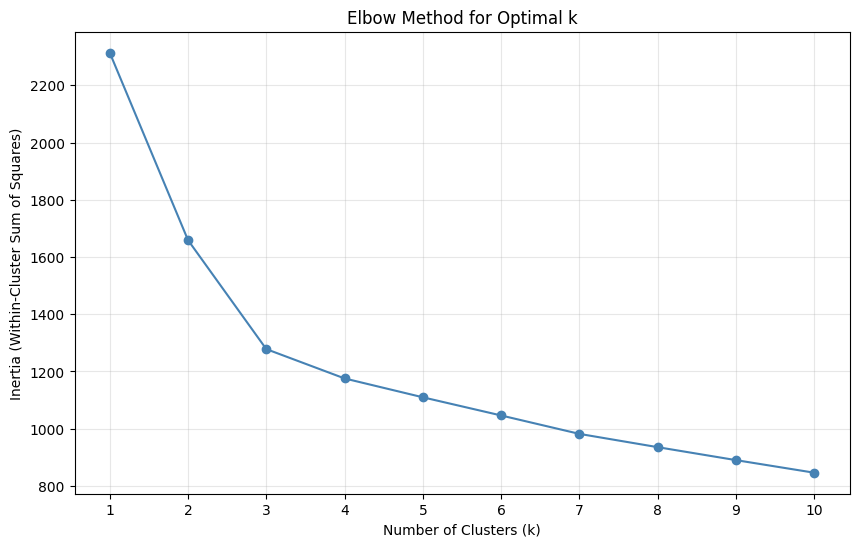

In [7]:
# --- Clustering: K-Means ---
# First, determine the optimal number of clusters using the Elbow Method

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

k=2: Silhouette Score = 0.2593
k=3: Silhouette Score = 0.2849
k=4: Silhouette Score = 0.2602
k=5: Silhouette Score = 0.2016
k=6: Silhouette Score = 0.2372
k=7: Silhouette Score = 0.2036
k=8: Silhouette Score = 0.1570
k=9: Silhouette Score = 0.1499
k=10: Silhouette Score = 0.1436


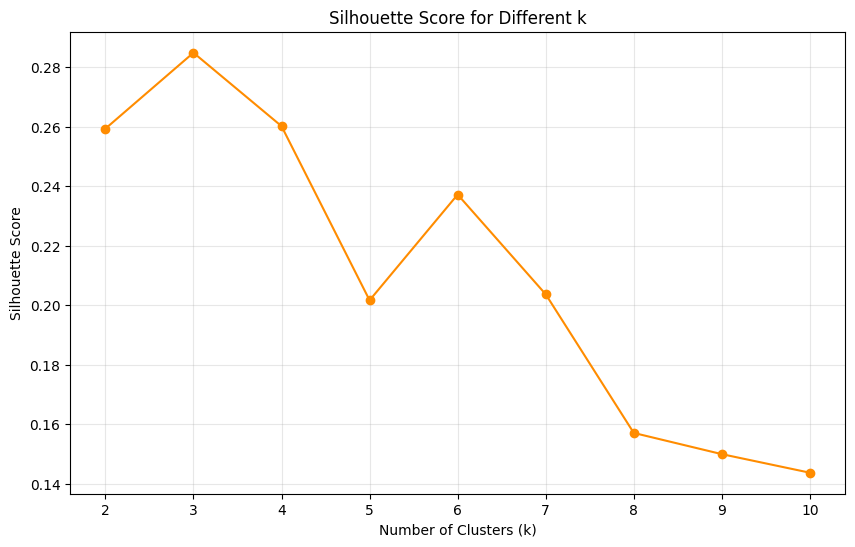

In [8]:
# Determine optimal k using Silhouette Score (a more objective complement to the Elbow method)

silhouette_scores = []
k_range_sil = range(2, 11)  # silhouette score requires at least 2 clusters

for k in k_range_sil:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range_sil, silhouette_scores, marker='o', color='darkorange')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_sil)
plt.grid(True, alpha=0.3)
plt.show()

### Optimal k Selection

Both the Elbow method and Silhouette score independently point to **k=3** as the optimal number
of clusters. The Elbow plot shows a sharp bend at k=3, after which inertia decreases only gradually.
The Silhouette score peaks at k=3 (≈0.285), dropping noticeably for k=4 and k=5 before a smaller
secondary local maximum at k=6. This strongly suggests 3 natural groupings in the data — which,
notably, matches the true number of wine cultivars (3) in the original dataset, even though that
label information was never used to determine k

In [9]:
# Run K-Means with the optimal k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"\nK-Means Silhouette Score (k=3): {kmeans_silhouette:.4f}")

Cluster sizes:
0    65
1    51
2    62
Name: count, dtype: int64

K-Means Silhouette Score (k=3): 0.2849


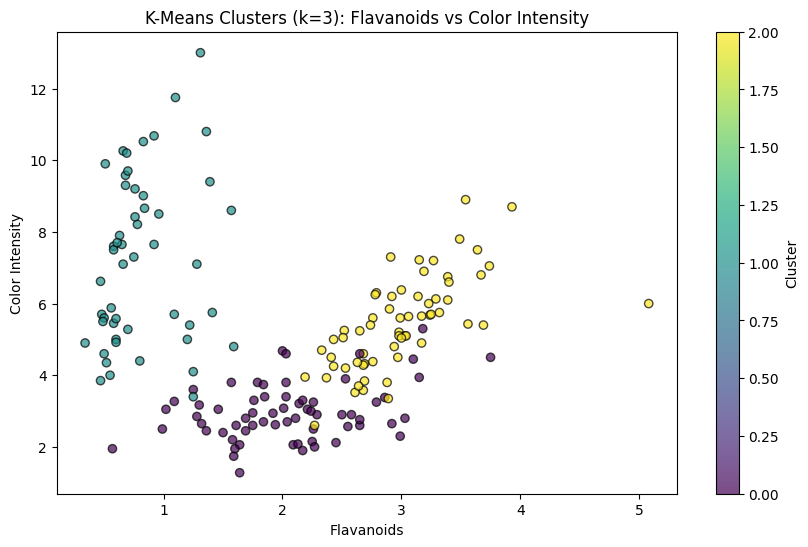

In [10]:
# Visualize using two of the most informative original features
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['flavanoids'], df['color_intensity'], c=kmeans_labels, cmap='viridis', alpha=0.7, edgecolor='black')
plt.title('K-Means Clusters (k=3): Flavanoids vs Color Intensity')
plt.xlabel('Flavanoids')
plt.ylabel('Color Intensity')
plt.colorbar(scatter, label='Cluster')
plt.show()

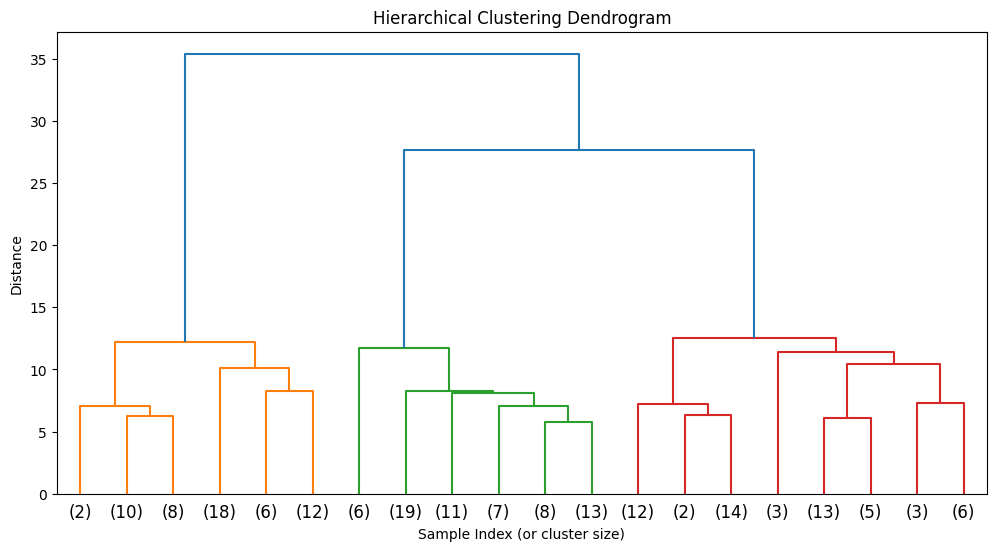

In [11]:
# --- Clustering: Hierarchical Clustering ---

# First, visualize the dendrogram to inspect the natural grouping structure
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index (or cluster size)')
plt.ylabel('Distance')
plt.show()

In [12]:
# Apply Agglomerative (Hierarchical) Clustering with 3 clusters, matching K-Means for fair comparison
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

print("Hierarchical cluster sizes:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
print(f"\nHierarchical Silhouette Score (k=3): {hierarchical_silhouette:.4f}")

Hierarchical cluster sizes:
0    58
1    56
2    64
Name: count, dtype: int64

Hierarchical Silhouette Score (k=3): 0.2774


### Clustering Method Comparison

K-Means (Silhouette = 0.2849) slightly outperformed Hierarchical Clustering (Silhouette = 0.2774)
on this dataset, though both produced very similar cluster sizes (~55-65 samples per cluster) and
comparable separation quality. This agreement between two fundamentally different algorithms — one
iterative/centroid-based, one bottom-up/distance-based — strengthens confidence that the 3-cluster
structure reflects genuine patterns in the chemical composition data, rather than an artifact of
either specific method

Explained variance ratio per component: [0.36198848 0.1920749 ]
Total variance explained by 2 components: 55.41%


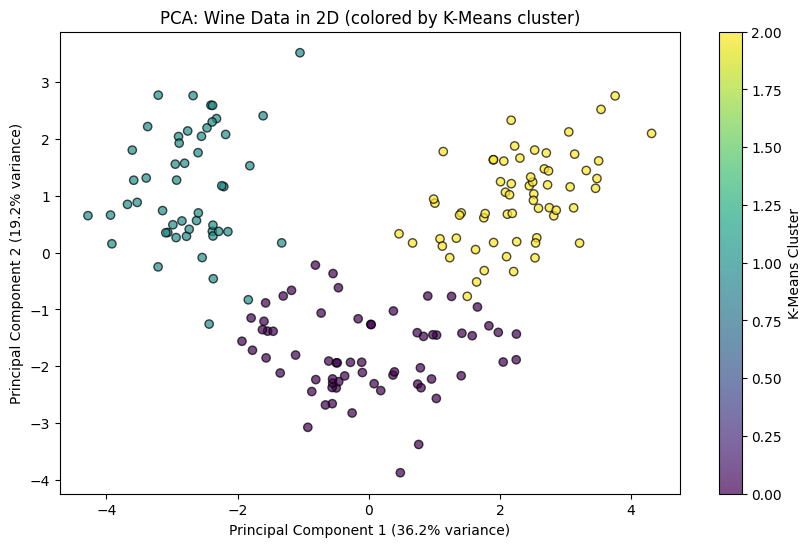

In [13]:
# --- Dimensionality Reduction: PCA ---

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_)*100:.2f}%")

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7, edgecolor='black')
plt.title('PCA: Wine Data in 2D (colored by K-Means cluster)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, label='K-Means Cluster')
plt.show()

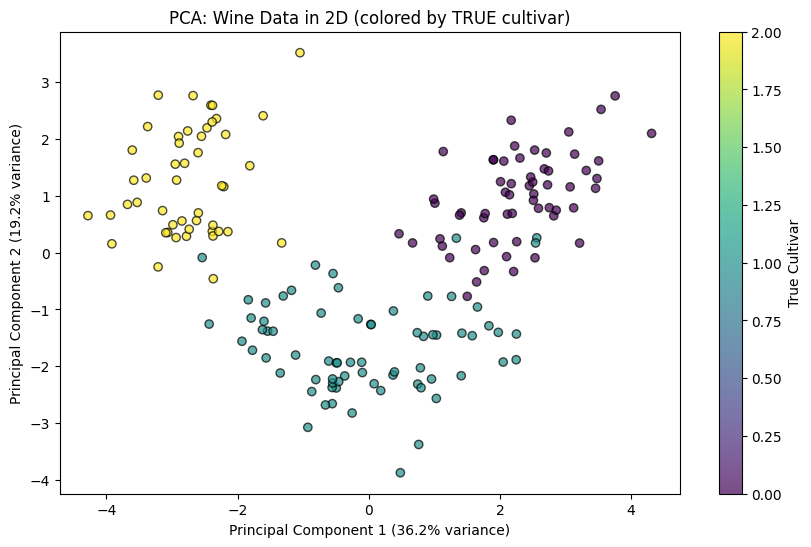

In [14]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels, cmap='viridis', alpha=0.7, edgecolor='black')
plt.title('PCA: Wine Data in 2D (colored by TRUE cultivar)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, label='True Cultivar')
plt.show()

### PCA Validation Against Ground Truth

When the same 2D PCA projection is colored by K-Means cluster assignment versus the true wine
cultivar, the groupings appear visually very similar. This is strong evidence that the clustering
genuinely captured real chemical differences between cultivars, rather than producing an arbitrary
or meaningless partition of the data. Since the true labels were never used during clustering, this
agreement was discovered, not engineered

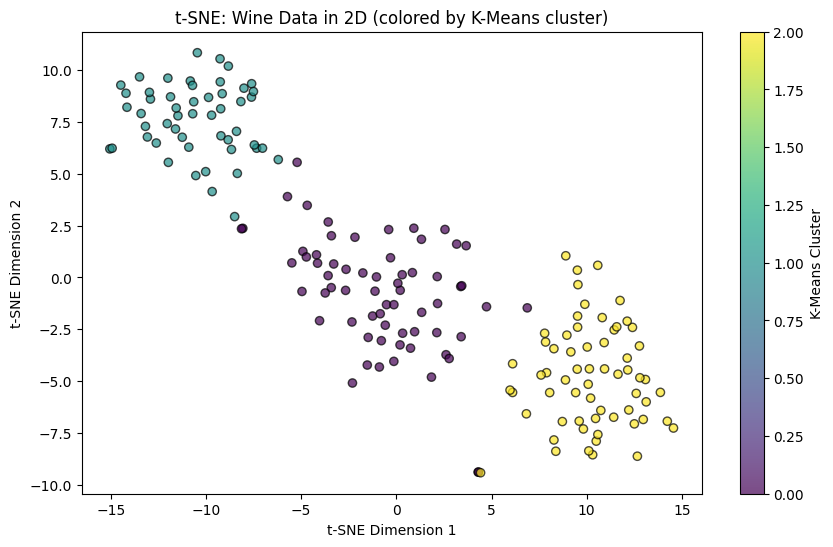

In [15]:
# --- Dimensionality Reduction: t-SNE ---

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7, edgecolor='black')
plt.title('t-SNE: Wine Data in 2D (colored by K-Means cluster)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='K-Means Cluster')
plt.show()

**Note on t-SNE:** unlike PCA's components, t-SNE's axes don't represent a meaningful direction in
the original feature space — only the relative distances between points are meaningful. `perplexity=30`
(a default, reasonable choice) controls how t-SNE balances local versus global structure; this dataset's
small size (178 samples) means smaller perplexity values would also be worth trying, though the default
already produces clear separation here

In [16]:
# --- Model Evaluation ---

print("=" * 50)
print("CLUSTERING EVALUATION SUMMARY")
print("=" * 50)
print(f"\nK-Means (k=3):")
print(f"  Silhouette Score: {kmeans_silhouette:.4f}")
print(f"  Cluster sizes: {dict(pd.Series(kmeans_labels).value_counts().sort_index())}")

print(f"\nHierarchical Clustering (k=3):")
print(f"  Silhouette Score: {hierarchical_silhouette:.4f}")
print(f"  Cluster sizes: {dict(pd.Series(hierarchical_labels).value_counts().sort_index())}")

print(f"\nPCA:")
print(f"  Total variance explained (2 components): {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Compare K-Means clusters to true labels using a confusion-matrix-style crosstab
print(f"\nK-Means clusters vs. true cultivar labels (cross-tabulation):")
comparison = pd.crosstab(kmeans_labels, true_labels, rownames=['K-Means Cluster'], colnames=['True Cultivar'])
print(comparison)

CLUSTERING EVALUATION SUMMARY

K-Means (k=3):
  Silhouette Score: 0.2849
  Cluster sizes: {0: np.int64(65), 1: np.int64(51), 2: np.int64(62)}

Hierarchical Clustering (k=3):
  Silhouette Score: 0.2774
  Cluster sizes: {0: np.int64(58), 1: np.int64(56), 2: np.int64(64)}

PCA:
  Total variance explained (2 components): 55.41%

K-Means clusters vs. true cultivar labels (cross-tabulation):
True Cultivar     0   1   2
K-Means Cluster            
0                 0  65   0
1                 0   3  48
2                59   3   0


### Final Evaluation Insights

K-Means slightly outperformed Hierarchical Clustering on Silhouette score (0.2849 vs 0.2774),
though both produced highly comparable cluster structures. The cross-tabulation against true
cultivar labels shows strong alignment: Cluster 0 maps perfectly to Cultivar 1 (65/65 points,
zero misassignment), Cluster 2 maps almost entirely to Cultivar 0 (59/62 points), and Cluster 1
maps almost entirely to Cultivar 2 (48/51 points). Only 6 of 178 points (about 3.4%) fell into a
cluster that didn't match their true cultivar — a strong result given that clustering never had
access to the cultivar labels. PCA's two components captured 55.41% of the original 13-dimensional
variance, a substantial amount for just 2 dimensions, which explains why the 2D visualizations were
already quite informative. A Silhouette score in the 0.27-0.29 range indicates moderate cluster
separation — not extremely tight, likely due to some genuine overlap in chemical composition between
neighboring cultivars — but the near-perfect recovery of the true grouping structure shows the
clustering captured real, meaningful patterns in the data

## Deployment & Monitoring

### Hypothetical Deployment Scenario

Imagine this clustering pipeline deployed for a wine producer or distributor who wants to
automatically classify incoming wine samples by their likely cultivar/style based on lab-measured
chemical properties (alcohol content, phenols, color intensity, etc.), without needing a human
sommelier to manually categorize each batch. The K-Means model (k=3) would be the best candidate
to deploy, given its slightly higher Silhouette score and near-perfect alignment with true cultivar
groupings observed during evaluation

### Deployment Approach

1. **Package the trained model and preprocessing together**: the fitted `StandardScaler` and
   `KMeans` model must be saved and deployed as a single unit (e.g., via `pickle` or `joblib`),
   since predictions on new samples require applying the *exact same* scaling parameters learned
   during training — not re-fitting a new scaler on each new batch.
2. **Serve via a REST API**: wrap the model in a lightweight API (e.g., Flask/FastAPI) with a
   `/predict` endpoint that accepts a new sample's 13 chemical measurements and returns its
   predicted cluster.
3. **Batch vs. real-time**: since lab measurements are likely produced in batches (e.g., after
   each day's testing), a batch-processing pipeline may be more practical than real-time inference
   for this particular use case

### Potential Deployment Challenges

- **Latency**: K-Means prediction itself is extremely fast (just a distance calculation to each
  cluster center), so latency is unlikely to be a major concern for this specific model — unlike
  more complex algorithms (e.g., SVM with many support vectors).
- **Scalability**: if sample volume grows significantly, scaling is straightforward since K-Means
  prediction is computationally cheap and embarrassingly parallel across samples.
- **Maintenance and data drift**: if a producer starts sourcing grapes from new regions or changes
  growing/processing techniques over time, the chemical "fingerprint" of each cultivar may shift,
  causing the original cluster boundaries to no longer reflect reality. The model assumes the input
  distribution stays similar to the training data — a violation of this assumption (e.g., from a new,
  previously unseen cultivar appearing) could result in poor cluster assignments with no built-in
  warning, since K-Means will always assign every point to its nearest existing cluster, even if that
  point doesn't truly belong anywhere close to it

### Monitoring and Updating Strategy

- **Track distributional drift**: periodically compare the distribution of new samples' features
  against the original training distribution (e.g., using statistical tests like Kolmogorov-Smirnov)
  to detect when incoming data starts looking meaningfully different.
- **Re-evaluate Silhouette scores on new data**: a sustained drop in Silhouette score for newly
  assigned points could signal that the existing cluster structure no longer fits well.
- **Scheduled retraining**: rather than retraining continuously, retrain on a fixed cadence (e.g.,
  quarterly, or after accumulating some threshold of new samples) using the latest labeled or
  semi-labeled data, validating the new clustering against the old one before fully replacing it in
  production.
- **Human-in-the-loop validation**: periodically have a small sample of model-assigned clusters
  manually reviewed by an expert (e.g., a sommelier or lab technician) to catch silent degradation
  that purely statistical monitoring might miss

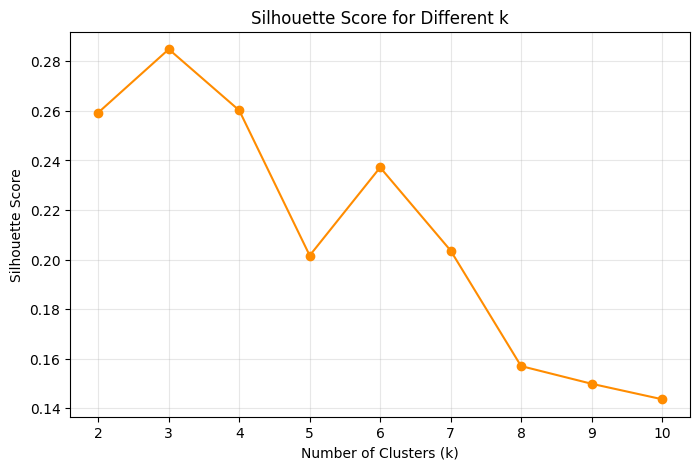

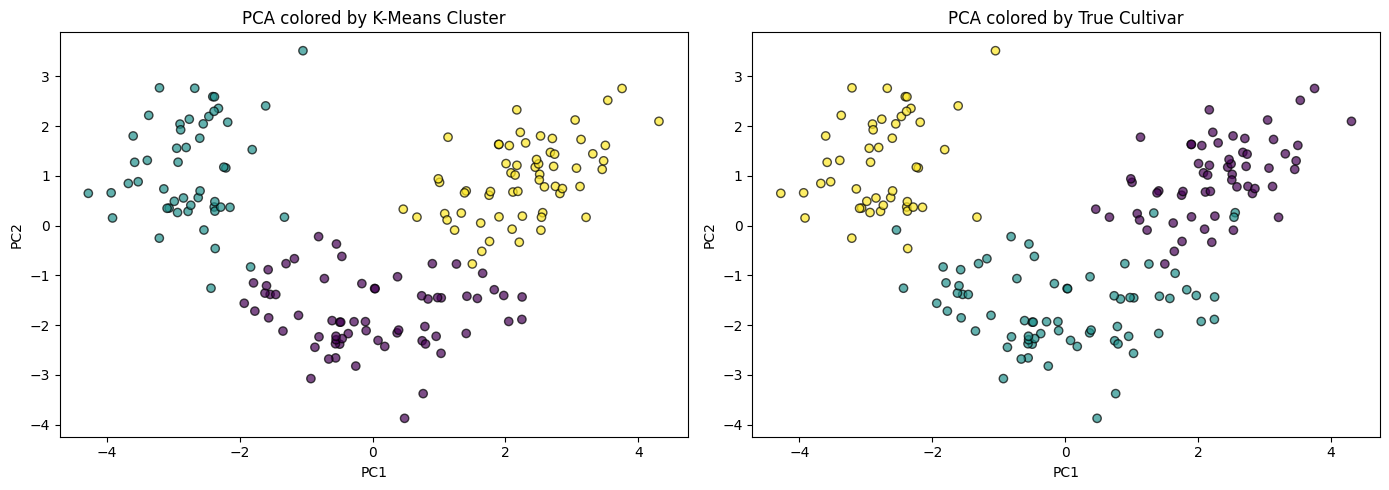

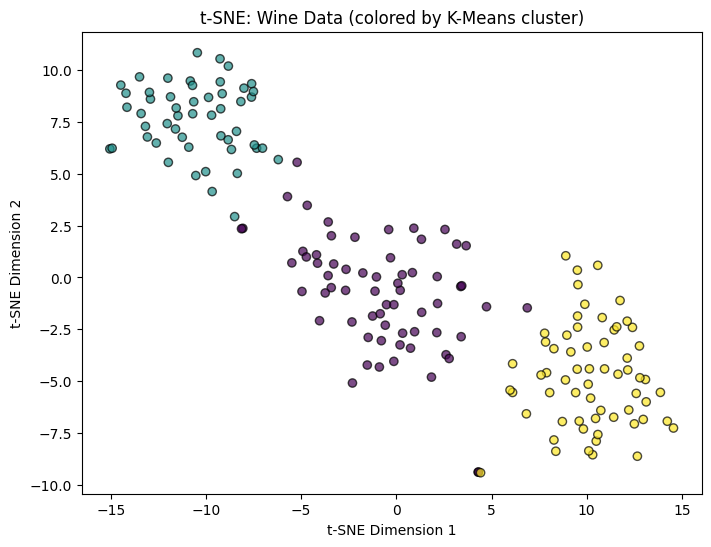

Figures saved.


In [17]:
import os
os.makedirs('figures', exist_ok=True)

# Re-create and save the key figures as PNG files for the report

# Figure 1: Silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_range_sil, silhouette_scores, marker='o', color='darkorange')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_sil)
plt.grid(True, alpha=0.3)
plt.savefig('figures/silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: PCA colored by K-Means vs true labels (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7, edgecolor='black')
axes[0].set_title('PCA colored by K-Means Cluster')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels, cmap='viridis', alpha=0.7, edgecolor='black')
axes[1].set_title('PCA colored by True Cultivar')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.savefig('figures/pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3: t-SNE
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7, edgecolor='black')
plt.title('t-SNE: Wine Data (colored by K-Means cluster)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.savefig('figures/tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figures saved.")

In [18]:
!git config --global user.name "conslcan"
!git config --global user.email "conslcan@gmail.com"
!git clone https://github.com/conslcan/Wejdan-Assignment2-Git-Colab.git

Cloning into 'Wejdan-Assignment2-Git-Colab'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 75 (delta 26), reused 51 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 2.10 MiB | 9.63 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [19]:
import os
base = '/content/Wejdan-Assignment2-Git-Colab/wine-clustering'
os.makedirs(f'{base}/figures', exist_ok=True)
os.makedirs(f'{base}/report', exist_ok=True)
print("Folders created.")

Folders created.
